In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import anndata as ad

from tqdm.notebook import tqdm
from scFM_density_estimation.models import *

In [2]:
plt.rcParams['figure.figsize'] = (10, 6)

In [725]:
n = 10
N = 20_000
cond_dim = 4
batch_size = 512

# locs = [[0 for _ in range(n)], np.random.choice([-1, 1], size=n), np.random.choice([-1, 1], size=n), np.random.choice([-2, 2], size=n)]
# locs = [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [-1, -1,  1, -1,  1,  1,  1, -1, -1,  1], [1,  1, -1, -1,  1,  1,  1, -1, -1,  1], [-2, -2,  2, -2,  2,  2,  2, -2, -2,  2]]
# locs = [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1,  1, -1, -1, -1, -1,  1,  1,  1,  1], [1, -1, -1,  1, -1, -1, -1,  1, -1, -1], [2,  2,  2,  2, -2,  2,  2,  2,  2, -2]]
locs = [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [2, 2, 0, 0, 0, 0, 2, 2, 2, 2], [2, 0, 0, 2, 0, 0, 0, 2, 0, 0], [3, 3, 3, 3, -1, 3, 3, 3, 3, -1]]

C = np.random.randint(low=0, high=cond_dim, size=(N))
X = np.concatenate([np.random.normal(loc=locs[c], scale=1, size=(1, n)) for c in C])

alpha = 0.999
ema_loss = None
model = ConditionalFlowMatching(input_dim=n, hidden_dims=[1024, 1024, 1024], cond_dim=cond_dim,
                                use_encoder=False, use_ot_sampler=False, sigma_min=1e-2).to("cuda")
optimizer = model.configure_optimizers()

X = torch.tensor(X).to("cuda").float()
C = F.one_hot(torch.tensor(C).long(), num_classes=cond_dim).to("cuda").float()

for k in tqdm(range(50000)):
    optimizer.zero_grad()

    indices = np.random.choice(range(X.shape[0]), size=batch_size, replace=False)
    loss = model.shared_step(X[indices], C[indices])
    
    loss.backward()
    optimizer.step()

    if ema_loss is None:
        ema_loss = loss.item()
    else:
        ema_loss = alpha * ema_loss + (1 - alpha) * loss.item() 

    if (k + 1) % 1000 == 0:
        print(f"Step {k+1}, EMA Loss: {ema_loss:.3f}")

  0%|          | 0/50000 [00:00<?, ?it/s]

Step 1000, EMA Loss: 2.920
Step 2000, EMA Loss: 2.082
Step 3000, EMA Loss: 1.772
Step 4000, EMA Loss: 1.655
Step 5000, EMA Loss: 1.611
Step 6000, EMA Loss: 1.594
Step 7000, EMA Loss: 1.587
Step 8000, EMA Loss: 1.582
Step 9000, EMA Loss: 1.581
Step 10000, EMA Loss: 1.580
Step 11000, EMA Loss: 1.580
Step 12000, EMA Loss: 1.579
Step 13000, EMA Loss: 1.578
Step 14000, EMA Loss: 1.578
Step 15000, EMA Loss: 1.577
Step 16000, EMA Loss: 1.576
Step 17000, EMA Loss: 1.575
Step 18000, EMA Loss: 1.575
Step 19000, EMA Loss: 1.575
Step 20000, EMA Loss: 1.574
Step 21000, EMA Loss: 1.574
Step 22000, EMA Loss: 1.573
Step 23000, EMA Loss: 1.570
Step 24000, EMA Loss: 1.571
Step 25000, EMA Loss: 1.572
Step 26000, EMA Loss: 1.572
Step 27000, EMA Loss: 1.573
Step 28000, EMA Loss: 1.573
Step 29000, EMA Loss: 1.573
Step 30000, EMA Loss: 1.573
Step 31000, EMA Loss: 1.572
Step 32000, EMA Loss: 1.572
Step 33000, EMA Loss: 1.572
Step 34000, EMA Loss: 1.572
Step 35000, EMA Loss: 1.572
Step 36000, EMA Loss: 1.571
S

In [726]:
print(locs)

C = np.random.randint(low=0, high=cond_dim, size=(N))
X = np.concatenate([np.random.normal(loc=locs[c], scale=1, size=(1, n)) for c in C])

data_samples = torch.tensor(X).to("cuda").float()
cond = F.one_hot(torch.tensor(C).long(), num_classes=cond_dim).to("cuda").float()

[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [2, 2, 0, 0, 0, 0, 2, 2, 2, 2], [2, 0, 0, 2, 0, 0, 0, 2, 0, 0], [3, 3, 3, 3, -1, 3, 3, 3, 3, -1]]


In [727]:
def div_fn_hutch_trace(u):
    def div_fn(x, eps):
        _, vjpfunc = torch.func.vjp(u, x)
        return (vjpfunc(eps)[0] * eps).sum()

    return div_fn

class NODEWrapper_with_trace_div(torch.nn.Module):
    def __init__(self, model, cond):
        super().__init__()
        self.model = model
        self.cond = cond
        self.div_fn, self.eps_fn = div_fn_hutch_trace, torch.randn_like

    def forward(self, t, x, *args, **kwargs):
        x = x[..., :-1]
        
        def vecfield(y):
            return self.model(y.unsqueeze(0), t, self.cond[:1]).squeeze()

        div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        dx = self.model(x, t, self.cond)
        return torch.cat([dx, div[:, None]], dim=-1)

class NODEWrapper_with_ratio(torch.nn.Module):
    def __init__(self, model, control, condition):
        super().__init__()
        self.model = model
        self.cond_v = control
        self.cond_u = condition
        self.div_fn, self.eps_fn = div_fn_hutch_trace, torch.randn_like

    def forward(self, t, x, *args, **kwargs):
        x = x[..., :-3]
        
        def vecfield(y):
            return self.model(y.unsqueeze(0), t, self.cond_v[:1]).squeeze() \
            - self.model(y.unsqueeze(0), t, self.cond_u[:1]).squeeze()
        
        div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        ut = self.model(x, t, self.cond_u)
        vt = self.model(x, t, self.cond_v)
        
        if model.sigma_min is None or model.sigma_min == 0:
            score = (t * vt - x) / (1 - t + 1e-2)
        else:
            score = (t * vt - x) / (1 - (1 - model.sigma_min) * t)
        correction_term = torch.linalg.vecdot(vt - ut, score)
        dr = div + correction_term
        
        return torch.cat([ut, dr[:, None], correction_term[:, None], torch.linalg.vecdot(torch.ones_like(score), score)[:, None]], dim=-1)

class NODEWrapper_with_ratio_tvf(torch.nn.Module):
    def __init__(self, model, control, condition, point):
        super().__init__()
        self.model = model
        self.cond_v = control
        self.cond_u = condition
        self.cond_f = point
        self.div_fn, self.eps_fn = div_fn_hutch_trace, torch.randn_like

    def forward(self, t, x, *args, **kwargs):
        x = x[..., :-1]
        
        def vecfield(y):
            return self.model(y.unsqueeze(0), t, self.cond_v[:1]).squeeze() \
            - self.model(y.unsqueeze(0), t, self.cond_u[:1]).squeeze()
        
        div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        ut = self.model(x, t, self.cond_u)
        vt = self.model(x, t, self.cond_v)
        ft = self.model(x, t, self.cond_f)
        
        if model.sigma_min is None or model.sigma_min == 0:
            score_u = (t * ut - x) / (1 - t + 1e-2)
        else:
            score_u = (t * ut - x) / (1 - (1 - model.sigma_min) * t)
        correction_term_u = torch.linalg.vecdot(ft - ut, score_u)
        
        if model.sigma_min is None or model.sigma_min == 0:
            score_v = (t * vt - x) / (1 - t + 1e-2)
        else:
            score_v = (t * vt - x) / (1 - (1 - model.sigma_min) * t)
        correction_term_v = torch.linalg.vecdot(vt - ft, score_v)
        
        dr = div + correction_term_u + correction_term_v
        
        return torch.cat([ft, dr[:, None]], dim=-1)

In [728]:
condition = np.array([0, 0, 0, 1])
control = np.array([1, 0, 0, 0])
mask_condition = np.all(cond.cpu().numpy() == condition, axis=1)
mask_control = np.all(cond.cpu().numpy() == control, axis=1)
mask_both = mask_condition | mask_control

log_condition_true = -0.5 * ((data_samples.cpu().numpy() - np.array(locs[np.argmax(condition)])) ** 2).sum(axis=1) - 0.5 * data_samples.shape[1] * np.log(2 * np.pi)
log_control_true = -0.5 * ((data_samples.cpu().numpy() - np.array(locs[np.argmax(control)])) ** 2).sum(axis=1) - 0.5 * data_samples.shape[1] * np.log(2 * np.pi)
log_ratio_true = log_condition_true - log_control_true

In [729]:
device = data_samples.device

node = NeuralODE(
    NODEWrapper_with_trace_div(model, torch.tensor(condition).float().expand(data_samples.shape[0], cond_dim).to(device)),
    solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)

with torch.no_grad():
    traj = node.trajectory(
        torch.cat([data_samples, torch.zeros(data_samples.shape[0], 1).to(device)], dim=-1),
        t_span=torch.linspace(1, 0, 100).to(device)
    )
z0, div = traj[-1][:, :-1], traj[-1][:, -1]
log_condition_hat = (-0.5 * (z0 ** 2).sum(dim=1) - 0.5 * z0.shape[1] * np.log(2 * np.pi) + div).cpu().numpy()

node = NeuralODE(
    NODEWrapper_with_trace_div(model, torch.tensor(control).float().expand(data_samples.shape[0], cond_dim).to(device)),
    solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)

with torch.no_grad():
    traj = node.trajectory(
        torch.cat([data_samples, torch.zeros(data_samples.shape[0], 1).to(device)], dim=-1),
        t_span=torch.linspace(1, 0, 100).to(device)
    )
z0, div = traj[-1][:, :-1], traj[-1][:, -1]
log_control_hat = (-0.5 * (z0 ** 2).sum(dim=1) - 0.5 * z0.shape[1] * np.log(2 * np.pi) + div).cpu().numpy()

log_ratio_hat = log_condition_hat - log_control_hat

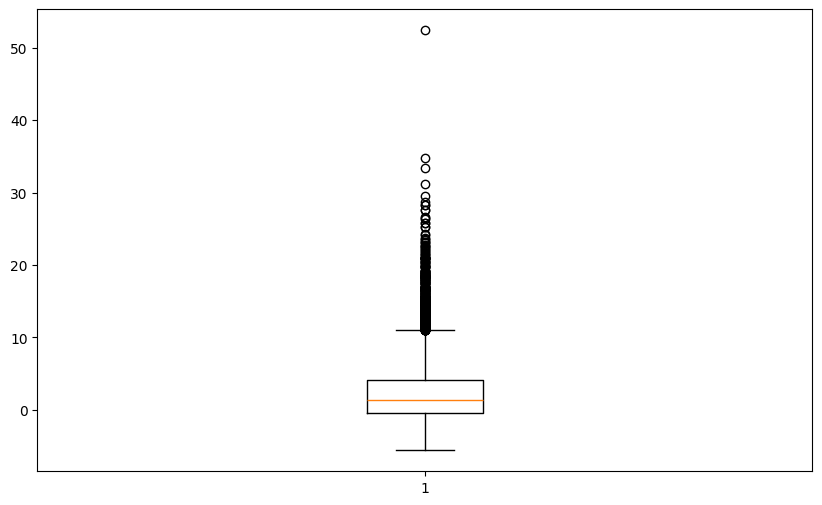

In [730]:
plt.boxplot((log_ratio_hat - log_ratio_true)[mask_both])
plt.show()

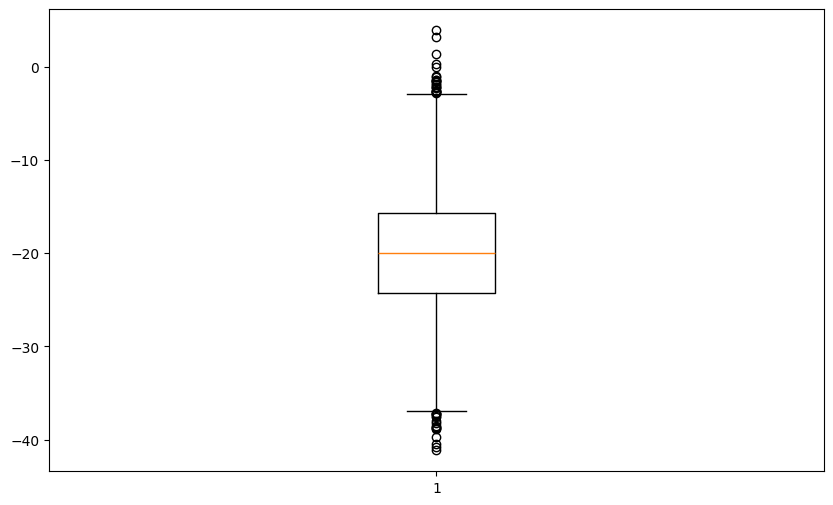

In [731]:
plt.boxplot(log_ratio_true[mask_control])
plt.show()

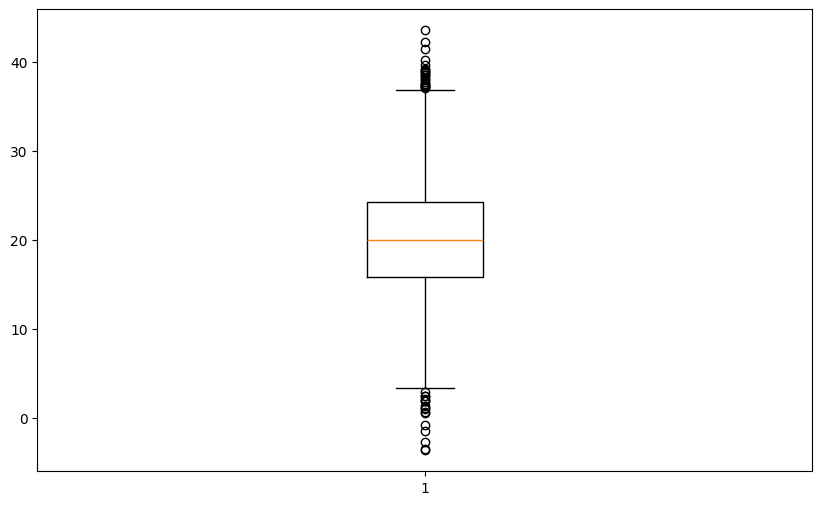

In [732]:
plt.boxplot(log_ratio_true[mask_condition])
plt.show()

In [733]:
obs = {"ratio": log_ratio_hat, "diff": log_ratio_hat - log_ratio_true, "cond": [str(i) for i in np.argmax(cond.cpu().numpy(), axis=1)]}
adata_direct = ad.AnnData(X=data_samples.cpu().numpy(), obs=obs)
adata_direct.obsm["X_pca"] = adata_direct.X.copy()

sc.pp.neighbors(adata_direct)
sc.tl.umap(adata_direct)

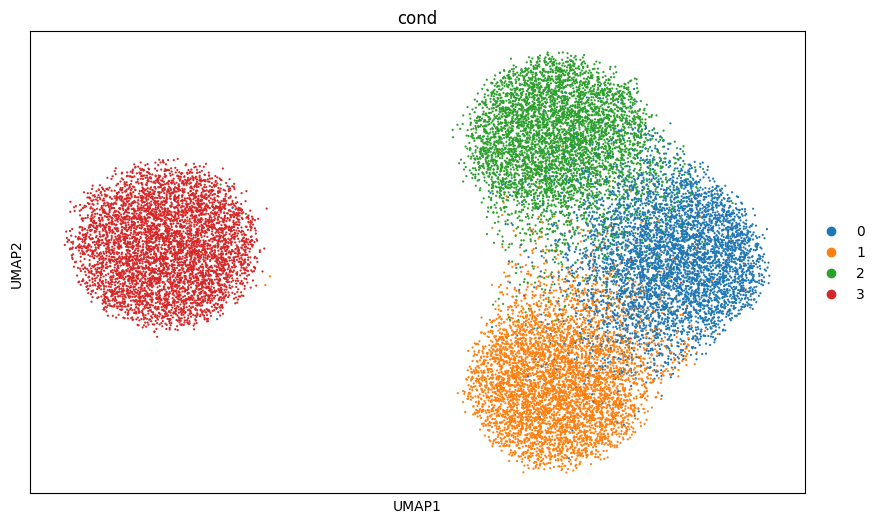

In [734]:
sc.pl.umap(adata_direct, color="cond", s=10)

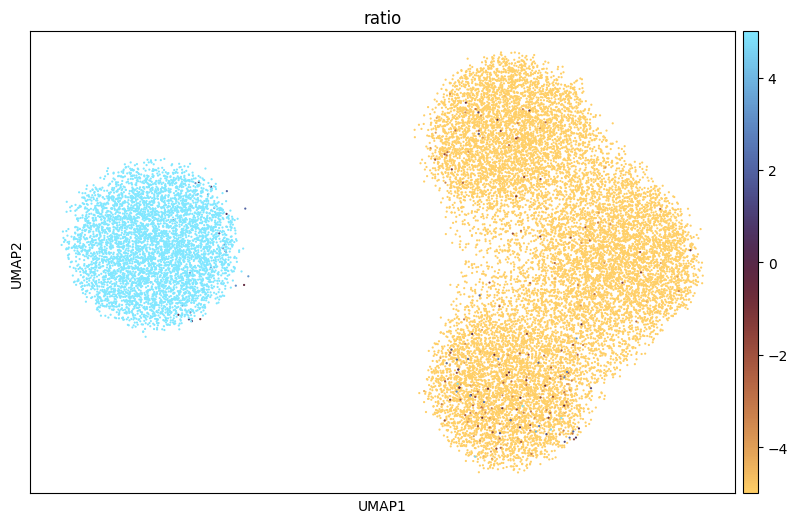

In [735]:
sc.pl.umap(adata_direct, color="ratio", s=10, cmap="managua", vcenter=0, vmax=5, vmin=-5)

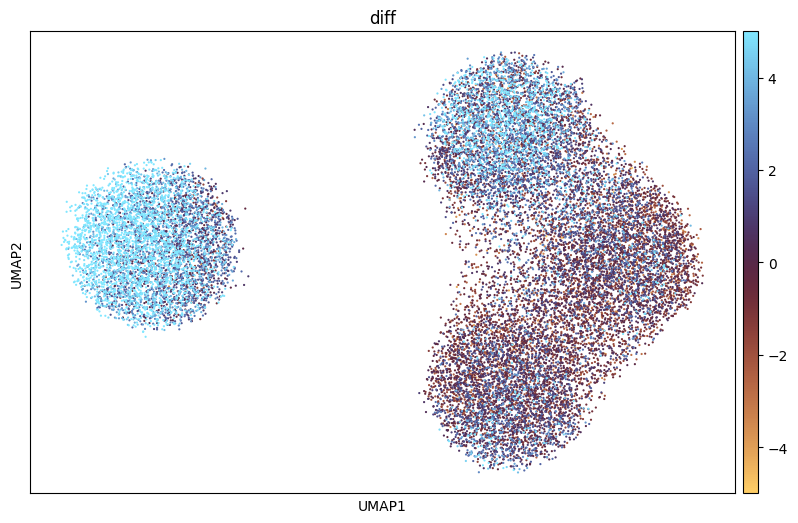

In [736]:
sc.pl.umap(adata_direct, color="diff", s=10, cmap="managua", vcenter=0, vmax=5, vmin=-5)

In [737]:
device = data_samples.device
node = NeuralODE(
    NODEWrapper_with_ratio(model, control=torch.tensor(control).float().expand(data_samples.shape[0], cond_dim).to(device),
                                  condition=torch.tensor(condition).float().expand(data_samples.shape[0], cond_dim).to(device)),
    solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)

with torch.no_grad():
    traj = node.trajectory(
        torch.cat([data_samples, torch.zeros(data_samples.shape[0], 3).to(device)], dim=-1),
        t_span=torch.linspace(1, 0, 100).to(device)
    )
z0, ratio, correction_term, score = traj[-1][:, :-3], traj[-1][:, -3], traj[-1][:, -2], traj[-1][:, -1]
log_ratio_hat_v2 = -ratio.cpu().numpy()

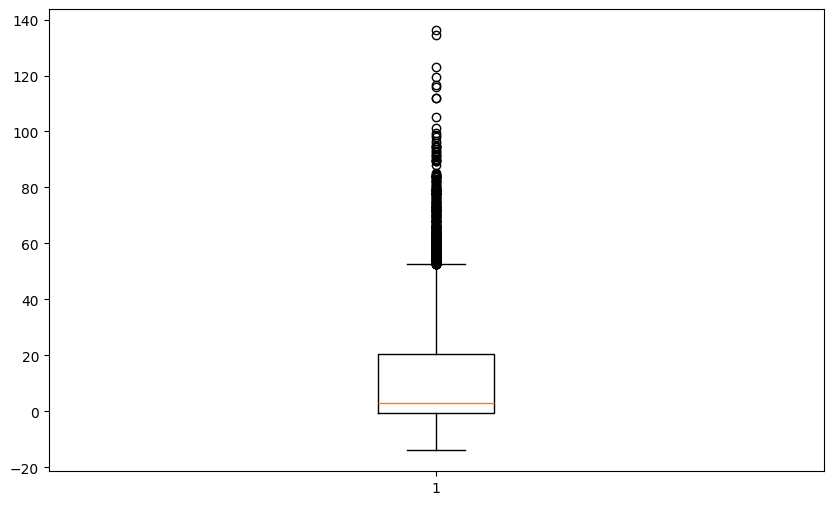

In [738]:
plt.boxplot((log_ratio_hat_v2 - log_ratio_true)[mask_both])
plt.show()

In [739]:
obs = {"ratio": log_ratio_hat_v2, "diff": log_ratio_hat_v2 - log_ratio_true, "cond": [str(i) for i in np.argmax(cond.cpu().numpy(), axis=1)]}
adata = ad.AnnData(X=data_samples.cpu().numpy(), obs=obs)
adata.obsm["X_pca"] = adata.X.copy()

sc.pp.neighbors(adata)
sc.tl.umap(adata)

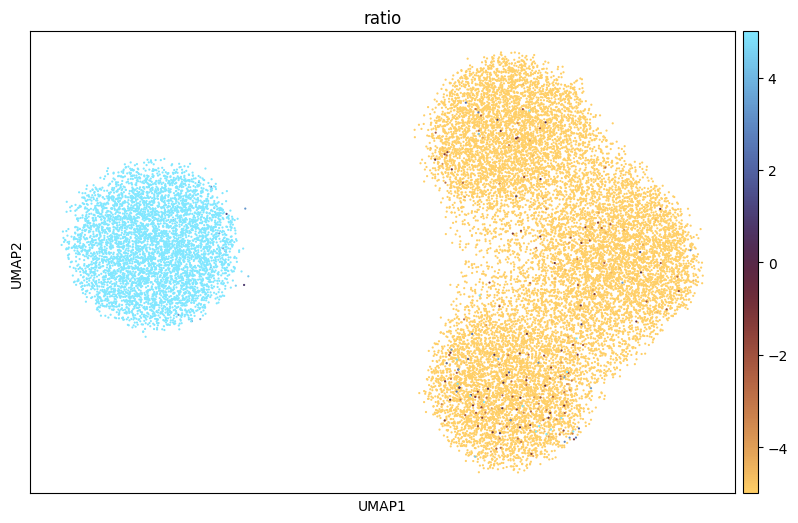

In [740]:
sc.pl.umap(adata, color="ratio", s=10, cmap="managua", vcenter=0, vmax=5, vmin=-5)

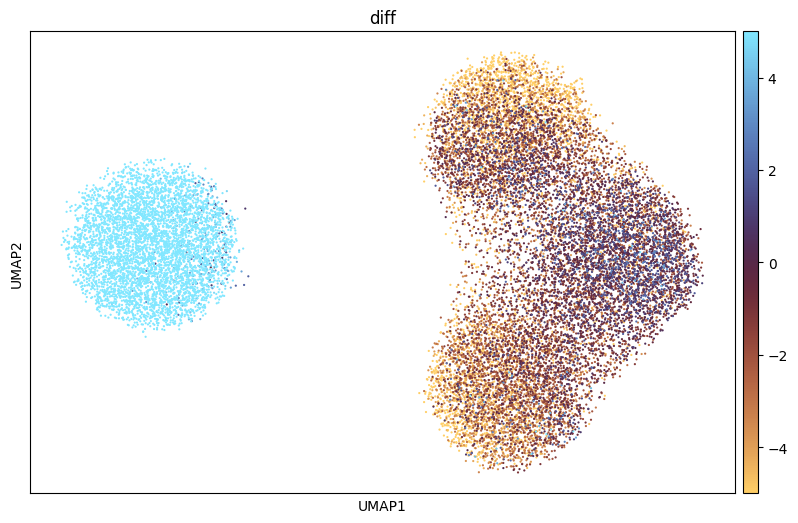

In [741]:
sc.pl.umap(adata, color="diff", s=10, cmap="managua", vcenter=0, vmax=5, vmin=-5)

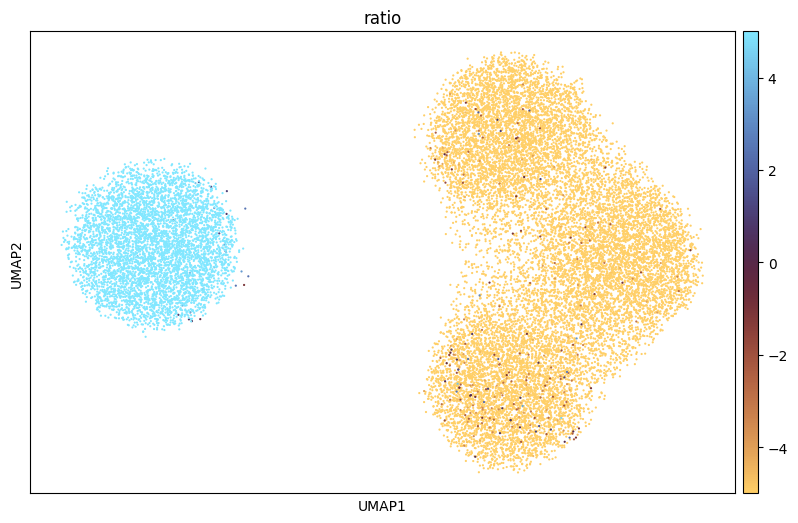

In [742]:
obs = {"ratio": log_ratio_true, "cond": [str(i) for i in np.argmax(cond.cpu().numpy(), axis=1)]}
adata_true = ad.AnnData(X=data_samples.cpu().numpy(), obs=obs)
adata_true.obsm["X_pca"] = adata_true.X.copy()

sc.pp.neighbors(adata_true)
sc.tl.umap(adata_true)
sc.pl.umap(adata_true, color="ratio", s=10, cmap="managua", vcenter=0, vmax=5, vmin=-5)

In [ ]:
device = data_samples.device
node = NeuralODE(
    NODEWrapper_with_ratio_tvf(model, control=torch.tensor(control).float().expand(data_samples.shape[0], cond_dim).to(device),
                           condition=torch.tensor(condition).float().expand(data_samples.shape[0], cond_dim).to(device), point=cond),
    solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)

with torch.no_grad():
    traj = node.trajectory(
        torch.cat([data_samples, torch.zeros(data_samples.shape[0], 1).to(device)], dim=-1),
        t_span=torch.linspace(1, 0, 100).to(device)
    )
z0, ratio = traj[-1][:, :-1], traj[-1][:, -1]
log_ratio_hat_v3 = -ratio.cpu().numpy()

In [ ]:
plt.boxplot((log_ratio_hat_v3 - log_ratio_true)[mask_both])
plt.show()

In [ ]:
obs = {"ratio": log_ratio_hat_v3, "diff": log_ratio_hat_v3 - log_ratio_true, "cond": [str(i) for i in np.argmax(cond.cpu().numpy(), axis=1)]}
adata_v3 = ad.AnnData(X=data_samples.cpu().numpy(), obs=obs)
adata_v3.obsm["X_pca"] = adata_v3.X.copy()

sc.pp.neighbors(adata_v3)
sc.tl.umap(adata_v3)

In [ ]:
sc.pl.umap(adata_v3, color="ratio", s=10, cmap="managua", vcenter=0, vmax=5, vmin=-5)

In [ ]:
sc.pl.umap(adata_v3, color="diff", s=10, cmap="managua", vcenter=0, vmax=5, vmin=-5)

In [ ]:
device = data_samples.device
node = NeuralODE(
    NODEWrapper_with_ratio(model, condition=torch.tensor(control).float().expand(data_samples.shape[0], cond_dim).to(device),
                                  control=torch.tensor(condition).float().expand(data_samples.shape[0], cond_dim).to(device)),
    solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)

with torch.no_grad():
    traj = node.trajectory(
        torch.cat([data_samples, torch.zeros(data_samples.shape[0], 3).to(device)], dim=-1),
        t_span=torch.linspace(1, 0, 2).to(device)
    )
z0, ratio, correction_term, score = traj[-1][:, :-3], traj[-1][:, -3], traj[-1][:, -2], traj[-1][:, -1]
log_ratio_hat_v4 = ratio.cpu().numpy()

In [ ]:
plt.boxplot((log_ratio_hat_v4 - log_ratio_true)[mask_both])
plt.show()

In [ ]:
obs = {"ratio": log_ratio_hat_v4, "diff": log_ratio_hat_v4 - log_ratio_true, "cond": [str(i) for i in np.argmax(cond.cpu().numpy(), axis=1)]}
adata_v4 = ad.AnnData(X=data_samples.cpu().numpy(), obs=obs)
adata_v4.obsm["X_pca"] = adata_v4.X.copy()

sc.pp.neighbors(adata_v4)
sc.tl.umap(adata_v4)

In [ ]:
sc.pl.umap(adata_v4, color="ratio", s=10, cmap="managua", vcenter=0, vmax=5, vmin=-5)

In [ ]:
sc.pl.umap(adata_v4, color="diff", s=10, cmap="managua", vcenter=0, vmax=5, vmin=-5)